###TELCO CUSTOMER CHURN PREDICTION
What is a *customer churn?* - it is when a customer decides to leave or stop using the company's services or products.

What are the possible causes of customer churn?
* Wrong target audience
* Bad customer support
* Better services and products from another competitor
* Product and services issues
* Improper pricing

To reduce customer churn, it is ideal for telecom companies to predict which customers have a high probability of leaving. The company will then create solutions or offers to that customer to reduce the risk of churn.

###LOADING LIBRARIES AND DATA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

###ANALYZE THE DATA
Each row represents a customer and each columns represents the customer's attributes

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In this dataset, our y-label is the *[Churn]* column and our X-features are all of the other columns

In [4]:
df.info() #check if the dataset have missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.shape

(7043, 21)

If we looked at the *[TotalCharges]* column, its Dtype is object. We have to convert its Dtype to a numerical type

In [6]:
#This converts the dtype to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isna().sum()) #This checks if there any missing values in the converted TotalCharges and get its sum

11


Since now we have some missing values in our dataset, we can just drop all of the rows that have missing values

In [7]:
df = df.dropna()
df = df.drop('customerID', axis=1) #we can also just remove this because its just an identifier
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

We have to convert our y-label into numerical representations

In [8]:
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

Create a bar graph to visualize how many customers stayed and churned based on the dataset

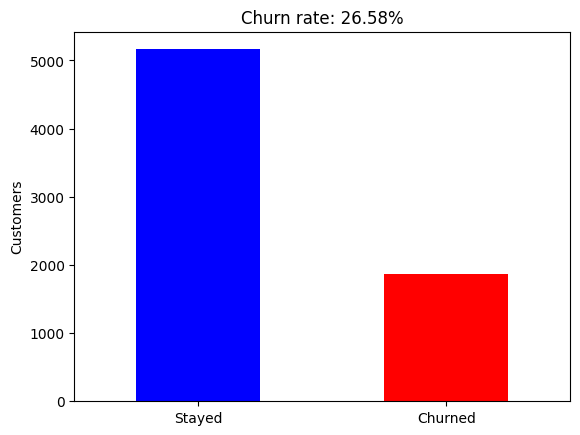

In [9]:
counts = df['Churn'].value_counts()
counts.index = ['Stayed', 'Churned']
counts.plot(kind='bar', color=['blue', 'red'])
plt.title(f"Churn rate: {df['Churn'].mean():.2%}")
plt.ylabel('Customers')
plt.xticks(rotation=0);

Based from the bar graph, more than 5000 customers stayed and less than 2000 customers churned

and our Churn rate is 26.58%

Create another bar graph to visualize all the categorical features. This can help us determine which categorical features we should look into more

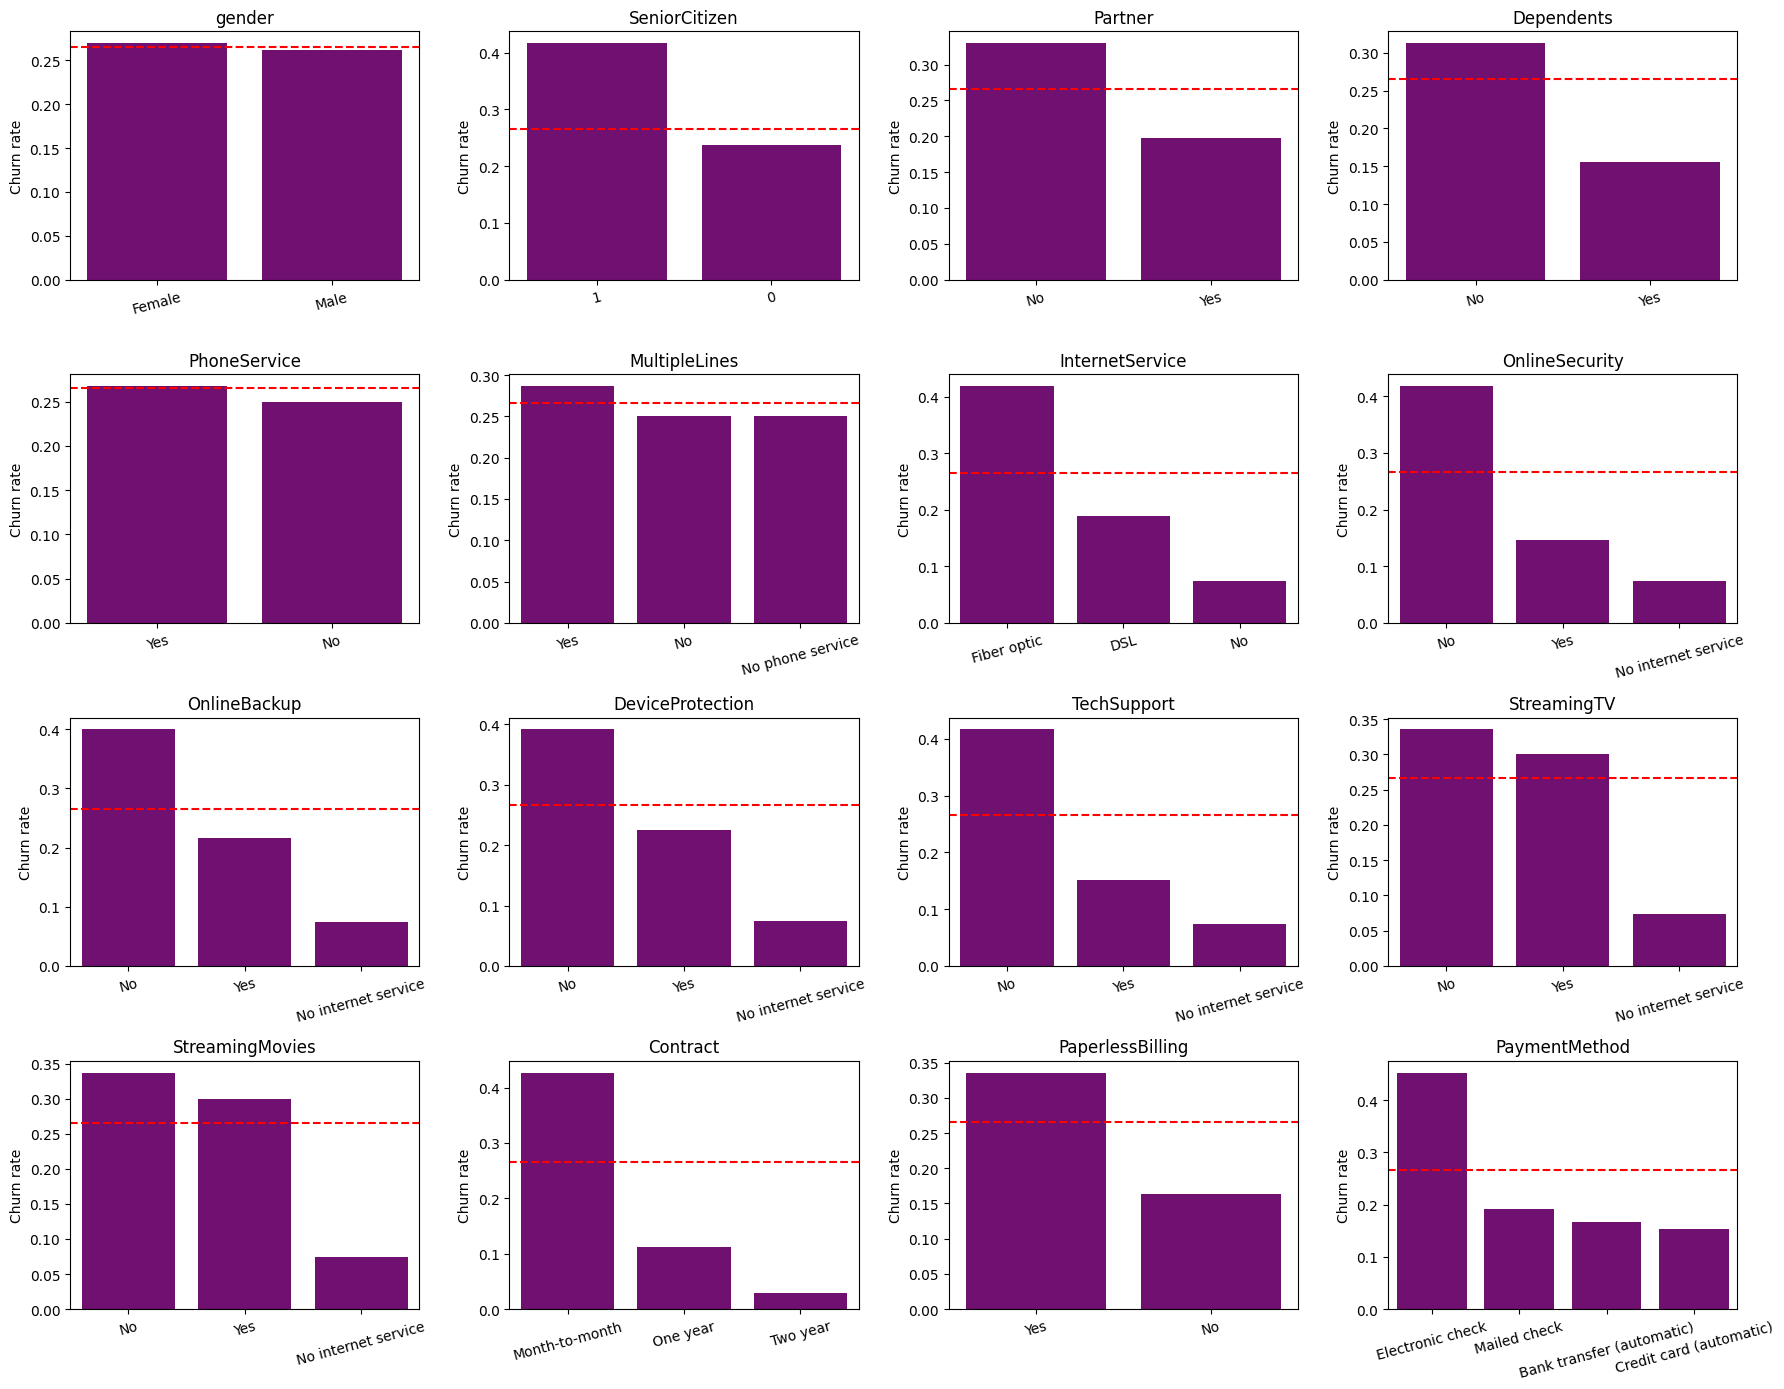

In [10]:
categories = [c for c in df.columns if c not in ['TotalCharges', 'MonthlyCharges', 'tenure', 'Churn']]
churn_line = df['Churn'].mean()

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
for ax, col in zip(axes.flat, categories):
  rates = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
  sns.barplot(x=rates.index.astype(str), y=rates.values, ax=ax, color='purple')
  ax.axhline(churn_line, color='red', ls='--')
  ax.set_title(col)
  ax.set_xlabel('')
  ax.set_ylabel('Churn rate')
  ax.tick_params(axis='x', rotation=15)
plt.tight_layout();

Based on the given graph, Both `[gender]` and `[PhoneService]` sits close to the red line. Which indicates these features might not have a strong association with churn

We can assess it and analyze it using **Chi-Square test**

Doing this can help us determine whether these features have a significant relationship with our y-label

p-value > 0.05 means insufficient evidence of association

p-value < 0.05 means strong evidence of association

In [11]:
test_features = ['gender', 'PhoneService']
for feat in test_features:
  table = pd.crosstab(df[feat], df['Churn'])
  chi2, p, dof, expected = chi2_contingency(table)
  print(f'{feat}: {p:.4f}')

gender: 0.4905
PhoneService: 0.3499


since both features scored above 0.05. It means both features do not have a strong relationship with the churn. Therefore, we can just drop it

In [12]:
df = df.drop(['gender', 'PhoneService'], axis=1)
df.head()

,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Yes,No,1,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,0,No,No,34,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,0,No,No,2,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,0,No,No,45,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,0,No,No,2,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


Create a histogram to visualize the numerical continuous features

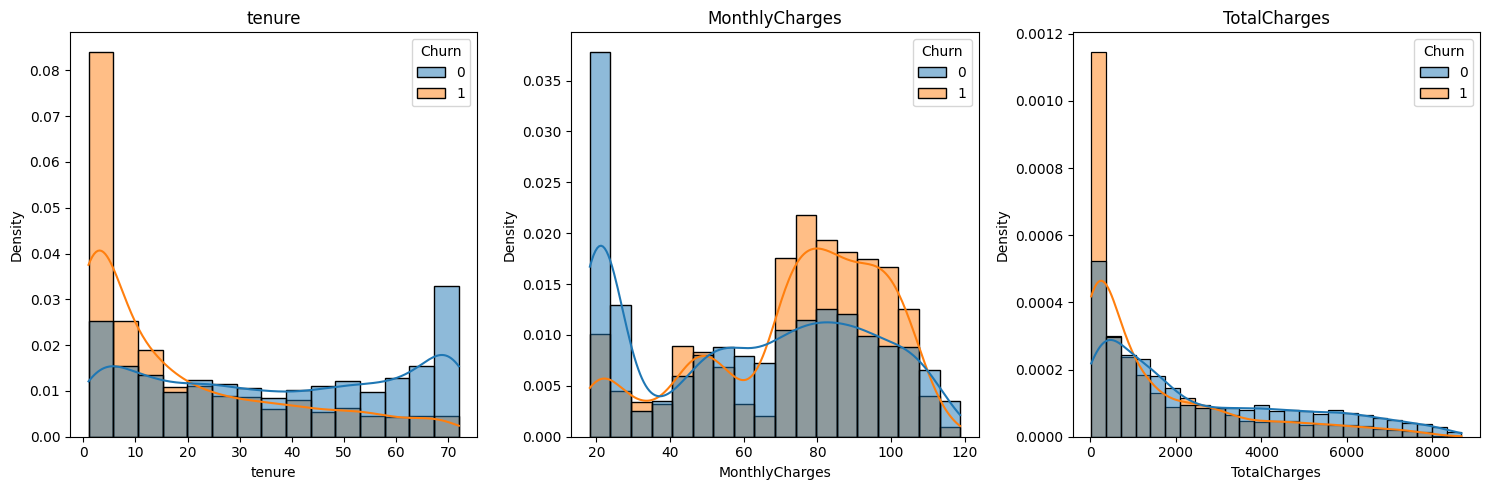

In [13]:
numericals = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes.flat, numericals):
  sns.histplot(data = df, x = col, hue='Churn', ax=ax, kde=True, stat='density', common_norm=False)
  ax.set_title(col)
plt.tight_layout()

**tenure** plot:

Most churned customers left within 15 months. which indicates most churned customers left early while long time customers tend to stay

**MonthlyCharges** plot:

Customers on low-cost plans (20-30) are much more likely to stay. The more the price increases, the more likely the customers to churn

**TotalCharges** plot:

Churned customers are concentrated at very low total charges. Which indicates most churned customers left early did not bill for long

We dont have to drop any of these features because they show an association
with churn

We can also visualize using heatmap to also analyze the given features and ylabel to see if it matches our histogram

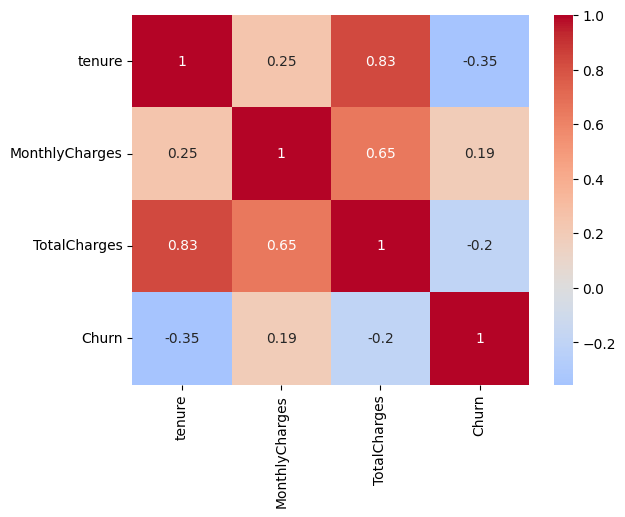

In [14]:
sns.heatmap(df[numericals + ['Churn']].corr(), annot=True, cmap='coolwarm', center=0)
plt.show()

Based on the given graph, tenure has the strongest negative correlation with churn, and total charges is strongly correlated with tenure

In [15]:
df.head()

,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Yes,No,1,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,0,No,No,34,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,0,No,No,2,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,0,No,No,45,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,0,No,No,2,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


###PREPROCESSING DATA

Turn categorical values into mathematical values

In [16]:
df.nunique()

,0
SeniorCitizen,2
Partner,2
Dependents,2
tenure,72
MultipleLines,3
InternetService,3
OnlineSecurity,3
OnlineBackup,3
DeviceProtection,3
TechSupport,3


In [17]:
df['Partner'] = (df['Partner'] == 'Yes').astype(int)
df['Dependents'] = (df['Dependents'] == 'Yes').astype(int)
df['PaperlessBilling'] = (df['PaperlessBilling'] == 'Yes').astype(int)


In [18]:
classifications = ['MultipleLines',	'InternetService',	'OnlineSecurity',	'OnlineBackup',	'DeviceProtection',	'TechSupport',	'StreamingTV',	'StreamingMovies',	'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=classifications, dtype=int)
df.head()

,SeniorCitizen,Partner,Dependents,tenure,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No,MultipleLines_No phone service,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,1,29.85,29.85,0,0,1,...,1,0,0,1,0,0,0,0,1,0
1,0,0,0,34,0,56.95,1889.50,0,1,0,...,1,0,0,0,1,0,0,0,0,1
2,0,0,0,2,1,53.85,108.15,1,1,0,...,1,0,0,1,0,0,0,0,0,1
3,0,0,0,45,0,42.30,1840.75,0,0,1,...,1,0,0,0,1,0,1,0,0,0
4,0,0,0,2,1,70.70,151.65,1,1,0,...,1,0,0,1,0,0,0,0,1,0


Split data into train and test sets

In [19]:
X = df.drop(['Churn'], axis=1)
y = df['Churn']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

feature scale the continuous values

In [21]:
numericals = ['tenure', 'MonthlyCharges',	'TotalCharges']
sc = StandardScaler()
X_train[numericals] = sc.fit_transform(X_train[numericals])
X_test[numericals] = sc.transform(X_test[numericals])

###TRAINING MODELS

We will be using the following models for training:
* Logistic Regression Model
* Naive Bayes Model

We then compare each models to see which model predicts better

Logistic Regression

In [22]:
logregModel = LogisticRegression(class_weight='balanced')
logregModel.fit(X_train, y_train)
y_pred = logregModel.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



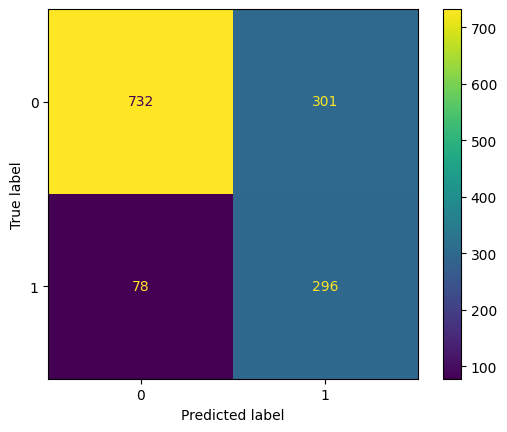

In [23]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()


Naive Bayes

In [24]:
gnbModel = GaussianNB().fit(X_train, y_train)
y_pred = gnbModel.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.62      0.74      1033
           1       0.45      0.85      0.59       374

    accuracy                           0.68      1407
   macro avg       0.68      0.73      0.66      1407
weighted avg       0.79      0.68      0.70      1407



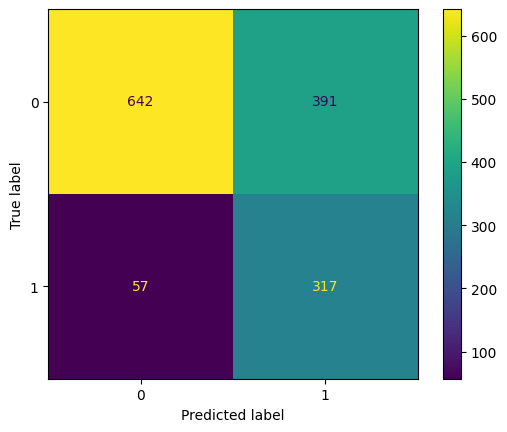

In [25]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

###EVALUATE RESULTS

Create a dataframe to compare the two models

In [26]:
models = {'Logistic Regression':logregModel, 'Naive Bayes':gnbModel}
rows = []

for name, model in models.items():
  y_pred = model.predict(X_test)
  rows.append({'Model': name,
               'Accuracy': (y_pred == y_test).mean(),
               'Precision': precision_score(y_test, y_pred),
               'Recall': recall_score(y_test, y_pred),
               'F1-score': f1_score(y_test, y_pred)})

results_dataframe = pd.DataFrame(rows).round(2)
results_dataframe

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.73,0.50,0.79,0.61
1,Naive Bayes,0.68,0.45,0.85,0.59


Create an RocCurveDisplay to visualize and compare the roc score of the two models

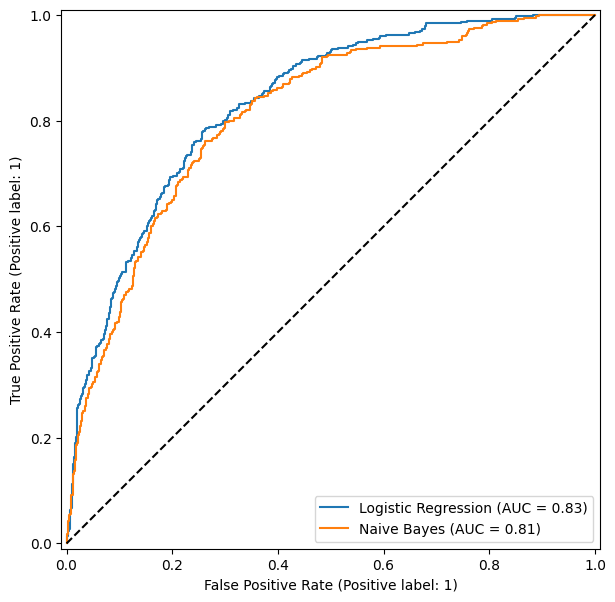

In [27]:
fig, ax = plt.subplots(figsize=(12, 7))
for name, model in models.items():
  RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)
ax.plot([0, 1], [0, 1], 'k--')
plt.show()

###CONCLUSION

Between the two models, the logistic regression model has a higher accuracy percentage and has a higher ROC AUC score than the naive bayes model. Although naive bayes model has a higher recall percentage which means it is better in predicting churn customers than the logistic regression model